# Impplemetn stochastic simulation for one dimension

In [10]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Tuple

import numpy as np


In [12]:
"""
Single-trajectory stochastic GC simulator – *with C-dependent T-cell help*
===========================================================================

Runs ONE germinal centre and prints population size and mean binding energy
after every 12-h round.

Author  : <your name>
Updated : 2025-07-05  –  adds C(t) factor in P_T(ε)
"""

from __future__ import annotations
from dataclasses import dataclass
import numpy as np


# ------------------------------------------------------------------ #
# 1. Parameters                                                      #
# ------------------------------------------------------------------ #
@dataclass(frozen=True)
class GCParams:
    N_i: int = 2_500          # initial population
    N_max: int = 2_500        # carrying capacity

    mu_i: float = 3.0         # initial ε ~ N(μ_i, σ_i²)
    sigma_i: float = 1.5

    # mutation probabilities
    p_let: float = 0.15       # lethal
    p_aa:  float = 0.10       # affinity-affecting
    p_sil: float = 0.75       # silent (implicit)

    # mutation kernel for affinity-affecting hits
    mu_M: float = 0.3
    sigma_M: float = 0.3

    eps_Ag: float = 0.0       # Ag-binding reference ε
    p_diff: float = 0.10      # differentiation probability


# ------------------------------------------------------------------ #
# 2. Antigen profile C(t)                                            #
# ------------------------------------------------------------------ #
def C_constant(_: int) -> float:
    """Constant concentration C = 5 for all rounds."""
    return 5.0


# ------------------------------------------------------------------ #
# 3. Simulator for a single GC                                       #
# ------------------------------------------------------------------ #
class SingleGCSimulator:
    def __init__(
        self,
        params: GCParams = GCParams(),
        *,
        T: int = 60,
        antigen_profile=C_constant,
        rng_seed: int | None = None,
    ) -> None:
        self.par = params
        self.T = int(T)
        self.C = antigen_profile
        self.rng = np.random.default_rng(rng_seed)

    # ---------------- mutation --------------------------------------
    def _mutate(self, eps: np.ndarray) -> np.ndarray:
        u = self.rng.random(eps.size)

        lethal = u < self.par.p_let
        aa     = (u >= self.par.p_let) & (u < self.par.p_let + self.par.p_aa)

        eps[aa] += self.rng.normal(self.par.mu_M, self.par.sigma_M, aa.sum())
        return eps[~lethal]     # survivors

    # ---------------- Ag binding ------------------------------------
    def _select_Ag(self, eps: np.ndarray, C_t: float) -> np.ndarray:
        if eps.size == 0:
            return eps
        P_Ag = C_t * np.exp(-eps) / (C_t * np.exp(-eps) + np.exp(-self.par.eps_Ag))
        return eps[self.rng.random(eps.size) < P_Ag]

    # ---------------- T-cell help  (now includes C_t) ---------------
    def _select_T(self, eps: np.ndarray, C_t: float) -> np.ndarray:
        if eps.size == 0:
            return eps
        mean_eps = float(eps.mean())
        P_T = C_t * np.exp(-eps) / (C_t * np.exp(-eps) + np.exp(-mean_eps))
        return eps[self.rng.random(eps.size) < P_T]

    # ---------------- main loop -------------------------------------
    def run(self) -> None:
        par, rng = self.par, self.rng
        eps = rng.normal(par.mu_i, par.sigma_i, par.N_i)

        print(f"{'Round':>5} | {'Pop.':>6} | {'Mean ε':>8}")
        print("-" * 26)

        for t in range(1, self.T + 1):
            # 1. duplication
            eps = np.concatenate([eps, eps])

            # 2. mutation
            eps = self._mutate(eps)

            # 3. antigen binding
            C_t = self.C(t)
            eps = self._select_Ag(eps, C_t)

            # 4. T-cell help  (now uses same C_t)
            eps = self._select_T(eps, C_t)

            # 5. differentiation
            if eps.size:
                eps = eps[rng.random(eps.size) >= par.p_diff]

            # 6. carrying capacity
            if eps.size > par.N_max:
                eps = eps[rng.choice(eps.size, par.N_max, replace=False)]

            # print stats
            pop_size = eps.size
            mean_eps = np.nan if pop_size == 0 else eps.mean()
            print(f"{t:5d} | {pop_size:6d} | {mean_eps:8.3f}")

            if pop_size == 0:
                print("Population extinct – simulation stopped.")
                break


# ------------------------------------------------------------------ #
# 4. Run                                                             #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    sim = SingleGCSimulator(
        T=60,
        antigen_profile=C_constant,   # constant C = 5
        rng_seed=2025,
    )
    sim.run()


Round |   Pop. |   Mean ε
--------------------------
    1 |    804 |    1.450
    2 |    524 |    0.776
    3 |    433 |    0.394
    4 |    390 |    0.089
    5 |    381 |   -0.250
    6 |    376 |   -0.499
    7 |    373 |   -0.742
    8 |    419 |   -0.915
    9 |    473 |   -1.086
   10 |    556 |   -1.188
   11 |    604 |   -1.332
   12 |    685 |   -1.459
   13 |    799 |   -1.607
   14 |    915 |   -1.712
   15 |   1056 |   -1.849
   16 |   1225 |   -1.955
   17 |   1456 |   -2.036
   18 |   1711 |   -2.109
   19 |   2029 |   -2.175
   20 |   2460 |   -2.233
   21 |   2500 |   -2.270
   22 |   2500 |   -2.290
   23 |   2500 |   -2.317
   24 |   2500 |   -2.343
   25 |   2500 |   -2.374
   26 |   2500 |   -2.381
   27 |   2500 |   -2.393
   28 |   2500 |   -2.404
   29 |   2500 |   -2.405
   30 |   2500 |   -2.408
   31 |   2500 |   -2.412
   32 |   2500 |   -2.423
   33 |   2500 |   -2.434
   34 |   2500 |   -2.432
   35 |   2500 |   -2.438
   36 |   2500 |   -2.451
   37 |   2

C:\Users\maria\AppData\Local\Temp\ipykernel_13760\1913745992.py:68: RuntimeWarning: Mean of empty slice
  mean_eps = np.nanmean(eps_ts, axis=0)


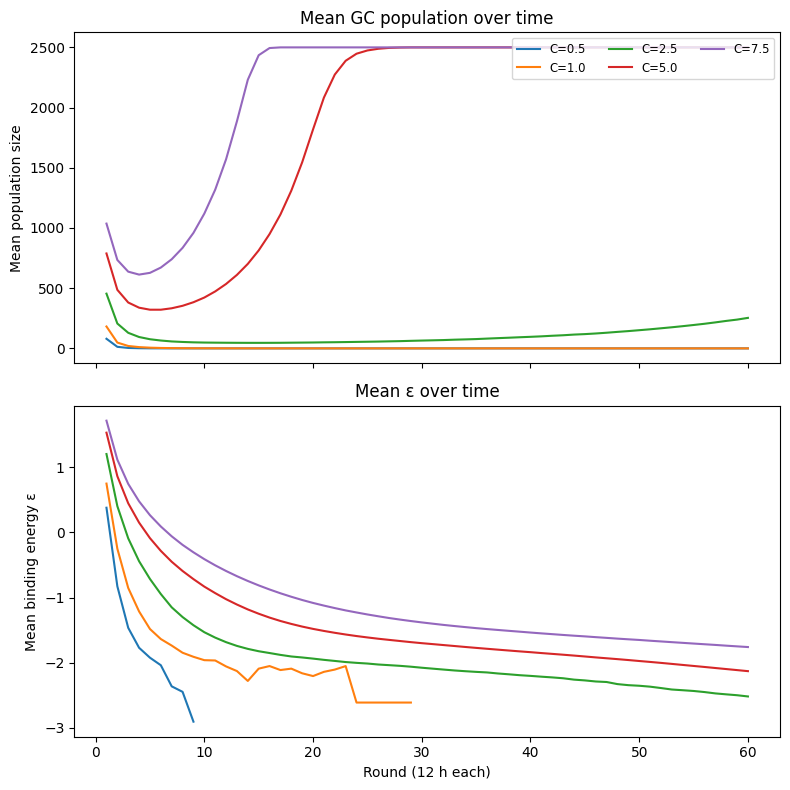

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Parameters -----------------------------------------------------------
@dataclass(frozen=True)
class GCParams:
    N_i: int = 2_500
    N_max: int = 2_500
    mu_i: float = 3.0
    sigma_i: float = 1.5
    p_let: float = 0.15
    p_aa: float = 0.10
    mu_M: float = 0.3
    sigma_M: float = 0.3
    eps_Ag: float = 0.0
    p_diff: float = 0.10

# --- Simulator returning time series -------------------------------------
def run_gc_timeseries(n_runs: int, C_const: float, T: int = 60, rng_seed: int = 0):
    par = GCParams()
    rng = np.random.default_rng(rng_seed)

    pop_ts = np.zeros((n_runs, T), dtype=np.int32)
    eps_ts = np.full((n_runs, T), np.nan, dtype=np.float32)

    for r in range(n_runs):
        eps = rng.normal(par.mu_i, par.sigma_i, par.N_i)
        for t in range(T):
            # duplication
            eps = np.concatenate([eps, eps])

            # mutation
            u = rng.random(eps.size)
            lethal = u < par.p_let
            aa = (u >= par.p_let) & (u < par.p_let + par.p_aa)
            eps[aa] += rng.normal(par.mu_M, par.sigma_M, aa.sum())
            eps = eps[~lethal]

            # Ag selection
            P_Ag = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-par.eps_Ag))
            eps = eps[rng.random(eps.size) < P_Ag]

            # T-cell help
            if eps.size:
                mean_eps = eps.mean()
                P_T = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-mean_eps))
                eps = eps[rng.random(eps.size) < P_T]

            # differentiation
            if eps.size:
                eps = eps[rng.random(eps.size) >= par.p_diff]

            # carrying capacity
            if eps.size > par.N_max:
                eps = eps[rng.choice(eps.size, par.N_max, replace=False)]

            # record time step stats
            pop_ts[r, t] = eps.size
            if eps.size:
                eps_ts[r, t] = eps.mean()

            if eps.size == 0:
                # remaining steps stay at 0 / nan
                break

    mean_pop = pop_ts.mean(axis=0)
    mean_eps = np.nanmean(eps_ts, axis=0)

    return mean_pop, mean_eps

# --- Run sweep over concentrations ---------------------------------------
concentrations = np.array([0.5, 1.0, 2.5, 5.0, 7.5])
n_runs = 300   # use 300 for runtime; adjust as needed
T = 60

all_mean_pop = []
all_mean_eps = []

for idx, C_val in enumerate(concentrations):
    m_pop, m_eps = run_gc_timeseries(n_runs, C_val, T=T, rng_seed=2025+idx)
    all_mean_pop.append(m_pop)
    all_mean_eps.append(m_eps)

all_mean_pop = np.array(all_mean_pop)  # shape (n_C, T)
all_mean_eps = np.array(all_mean_eps)

# --- Plotting ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Population subplot
for i, C_val in enumerate(concentrations):
    axes[0].plot(np.arange(1, T+1), all_mean_pop[i], label=f"C={C_val}")
axes[0].set_ylabel("Mean population size")
axes[0].set_title("Mean GC population over time")

# Energy subplot
for i, C_val in enumerate(concentrations):
    axes[1].plot(np.arange(1, T+1), all_mean_eps[i], label=f"C={C_val}")
axes[1].set_xlabel("Round (12 h each)")
axes[1].set_ylabel("Mean binding energy ε")
axes[1].set_title("Mean ε over time")

# Legend
axes[0].legend(loc='upper right', ncol=3, fontsize='small')

plt.tight_layout()
plt.show()


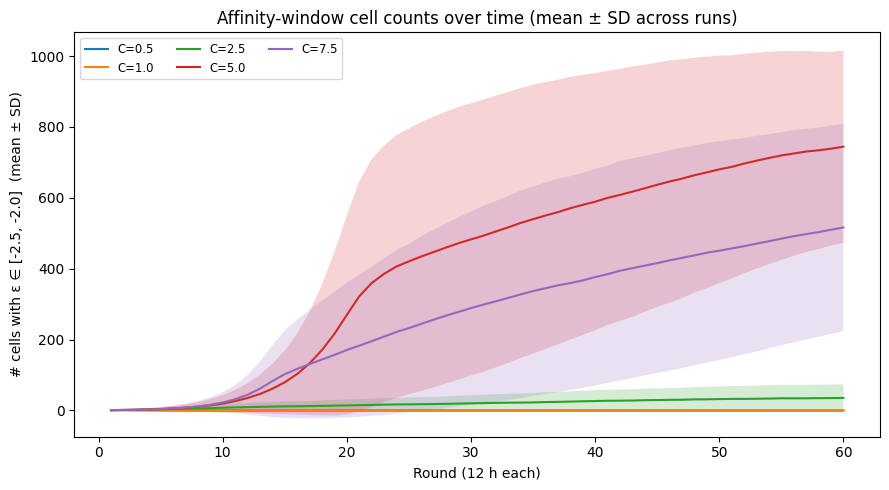

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Parameters -----------------------------------------------------------
@dataclass(frozen=True)
class GCParams:
    N_i: int = 2_500
    N_max: int = 2_500
    mu_i: float = 3.0
    sigma_i: float = 1.5
    p_let: float = 0.15
    p_aa: float = 0.10
    mu_M: float = 0.3
    sigma_M: float = 0.3
    eps_Ag: float = 0.0
    p_diff: float = 0.10

RANGE_LOW, RANGE_HIGH = -3, -2.0   # ε window centeres on -2.5

# --- Simulator returning mean+std series ---------------------------------
def run_gc_range_timeseries_stats(n_runs: int, C_const: float, T: int = 60, rng_seed: int = 0):
    par = GCParams()
    rng = np.random.default_rng(rng_seed)

    counts = np.zeros((n_runs, T), dtype=np.int32)

    for r in range(n_runs):
        eps = rng.normal(par.mu_i, par.sigma_i, par.N_i)

        for t in range(T):
            eps = np.concatenate([eps, eps])  # duplication

            # mutation
            u = rng.random(eps.size)
            lethal = u < par.p_let
            aa = (u >= par.p_let) & (u < par.p_let + par.p_aa)
            eps[aa] += rng.normal(par.mu_M, par.sigma_M, aa.sum())
            eps = eps[~lethal]

            # Ag binding
            P_Ag = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-par.eps_Ag))
            eps = eps[rng.random(eps.size) < P_Ag]

            # T-cell help (uses same C)
            if eps.size:
                mean_eps = eps.mean()
                P_T = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-mean_eps))
                eps = eps[rng.random(eps.size) < P_T]

            # differentiation
            if eps.size:
                eps = eps[rng.random(eps.size) >= par.p_diff]

            # carrying capacity
            if eps.size > par.N_max:
                eps = eps[rng.choice(eps.size, par.N_max, replace=False)]

            # record
            counts[r, t] = np.sum((eps >= RANGE_LOW) & (eps <= RANGE_HIGH))

            if eps.size == 0:
                # remaining steps stay at 0
                break

    mean_counts = counts.mean(axis=0)
    std_counts = counts.std(axis=0, ddof=1)
    return mean_counts, std_counts

# --- Concentration sweep --------------------------------------------------
concentrations = np.array([0.5, 1.0, 2.5, 5.0, 7.5])
n_runs = 300
T = 60

mean_time = []
std_time = []

for idx, C_val in enumerate(concentrations):
    m, s = run_gc_range_timeseries_stats(n_runs, C_val, T=T, rng_seed=2025+idx)
    mean_time.append(m)
    std_time.append(s)

mean_time = np.array(mean_time)  # shape (n_C, T)
std_time = np.array(std_time)

# --- Plotting -------------------------------------------------------------
plt.figure(figsize=(9, 5))
x = np.arange(1, T + 1)

for i, C_val in enumerate(concentrations):
    plt.plot(x, mean_time[i], label=f"C={C_val}")
    plt.fill_between(x, mean_time[i] - std_time[i], mean_time[i] + std_time[i], alpha=0.2)

plt.xlabel("Round (12 h each)")
plt.ylabel(f"# cells with ε ∈ [{RANGE_LOW}, {RANGE_HIGH}]  (mean ± SD)")
plt.title("Affinity-window cell counts over time (mean ± SD across runs)")
plt.legend(ncol=3, fontsize='small')
plt.tight_layout()
plt.show()


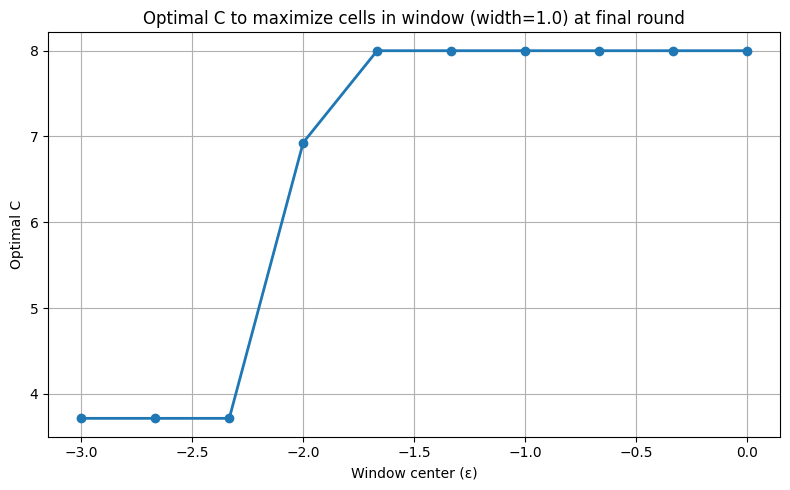

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Parameters -----------------------------------------------------------
@dataclass(frozen=True)
class GCParams:
    N_i: int = 2_500
    N_max: int = 2_500
    mu_i: float = 3.0
    sigma_i: float = 1.5
    p_let: float = 0.15
    p_aa: float = 0.10
    mu_M: float = 0.3
    sigma_M: float = 0.3
    eps_Ag: float = 0.0
    p_diff: float = 0.10

# --- Simulator ------------------------------------------------------------
def run_gc_range_timeseries_stats(n_runs: int, C_const: float, RANGE_LOW: float, RANGE_HIGH: float,
                                  T: int = 60, rng_seed: int = 0):
    par = GCParams()
    rng = np.random.default_rng(rng_seed)

    counts = np.zeros((n_runs, T), dtype=np.int32)

    for r in range(n_runs):
        eps = rng.normal(par.mu_i, par.sigma_i, par.N_i)

        for t in range(T):
            eps = np.concatenate([eps, eps])  # duplication

            # mutation
            u = rng.random(eps.size)
            lethal = u < par.p_let
            aa = (u >= par.p_let) & (u < par.p_let + par.p_aa)
            eps[aa] += rng.normal(par.mu_M, par.sigma_M, aa.sum())
            eps = eps[~lethal]

            # Ag binding
            P_Ag = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-par.eps_Ag))
            eps = eps[rng.random(eps.size) < P_Ag]

            # T-cell help
            if eps.size:
                mean_eps = eps.mean()
                P_T = C_const * np.exp(-eps) / (C_const * np.exp(-eps) + np.exp(-mean_eps))
                eps = eps[rng.random(eps.size) < P_T]

            # differentiation
            if eps.size:
                eps = eps[rng.random(eps.size) >= par.p_diff]

            # carrying capacity
            if eps.size > par.N_max:
                eps = eps[rng.choice(eps.size, par.N_max, replace=False)]

            # record window counts
            counts[r, t] = np.sum((eps >= RANGE_LOW) & (eps <= RANGE_HIGH))

            if eps.size == 0:
                break

    mean_counts = counts.mean(axis=0)
    std_counts = counts.std(axis=0, ddof=1)
    return mean_counts, std_counts

# --- Sweep: window centers & C for each window ---------------------------
window_centers = np.linspace(-3.0, 0.0, 10)  # adjust as needed
window_width = 1.0

concentration_grid = np.linspace(0.5, 8.0, 8)  # test different C values
n_runs = 200
T = 60

optimal_Cs = []
max_counts = []

for wc in window_centers:
    RANGE_LOW = wc - window_width / 2
    RANGE_HIGH = wc + window_width / 2

    best_C = None
    best_count = -np.inf

    for C_val in concentration_grid:
        mean_counts, _ = run_gc_range_timeseries_stats(
            n_runs, C_val, RANGE_LOW, RANGE_HIGH, T=T, rng_seed=123 + int(10 * wc) + int(C_val * 10)
        )

        final_count = mean_counts[-1]
        if final_count > best_count:
            best_count = final_count
            best_C = C_val

    optimal_Cs.append(best_C)
    max_counts.append(best_count)

# --- Plot ---------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(window_centers, optimal_Cs, 'o-', lw=2)
plt.xlabel("Window center (ε)")
plt.ylabel("Optimal C")
plt.title(f"Optimal C to maximize cells in window (width={window_width}) at final round")
plt.grid(True)
plt.tight_layout()
plt.show()
